# Multimodal Mineral Classification System - V2
## Deep Learning with Real Audio Data

---

**Project:** AI-Powered Mineral Identification and Traceability

**Objective:** Train a multimodal deep learning model to classify minerals (Gold, Chalcopyrite, Hematite) using three data modalities:
-  **Image features** (ResNet18-based CNN)
-  **Audio features** (Real MFCC spectrograms from field recordings)
-  **Chemical composition** (Au, Cu, Fe, S, O)

**Update (March 23, 2026):** Dataset now includes 38 real audio files from field collection, distributed across all 443 training samples.

---
#  Step 1: Import Required Libraries
Import all necessary packages for data processing, deep learning, and visualization.

In [1]:
# Core Libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# PyTorch & Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T

# Custom Modules
from multimodal_dataset import MultiModalDataset
from multimodal_model import MultiModalNet

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
torch.manual_seed(42)

print(" All libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

 All libraries imported successfully!
PyTorch Version: 2.10.0+cpu
CUDA Available: False


---
#  Step 2: Load and Explore Dataset
Load training and test CSV files and preview the data structure.

In [2]:
# Load CSV files
train_df_full = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Create validation split from train only (no test leakage)
train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.2,
    random_state=42,
    stratify=train_df_full['mineral']
)

# Persist split for reproducibility in later cells
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
train_df.to_csv('train_internal.csv', index=False)
val_df.to_csv('val_internal.csv', index=False)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\n Training samples: {len(train_df)}")
print(f" Validation samples: {len(val_df)}")
print(f" Test samples: {len(test_df)}")
print(f" Total samples: {len(train_df) + len(val_df) + len(test_df)}")
print(f"\n Columns: {list(train_df.columns)}")
print(f"\n Data types:\n{train_df.dtypes}")

DATASET OVERVIEW

 Training samples: 354
 Validation samples: 89
 Test samples: 261
 Total samples: 704

 Columns: ['sample_id', 'site', 'mineral', 'image_path', 'audio_path', 'Au', 'Cu', 'Fe', 'S', 'O']

 Data types:
sample_id         str
site              str
mineral           str
image_path        str
audio_path        str
Au            float64
Cu            float64
Fe            float64
S             float64
O             float64
dtype: object


### 2.1 Preview First 5 Training Samples

In [3]:
print("\n" + "=" * 80)
print("FIRST 5 TRAINING SAMPLES")
print("=" * 80 + "\n")
train_df.head()


FIRST 5 TRAINING SAMPLES



,sample_id,site,mineral,image_path,audio_path,Au,Cu,Fe,S,O
0,S00011,Kapoeta_East,gold,images\Kapoeta_East\gold\011755700175578041981...,audio\Dataset\gold\Dataset_gold_001.wav,92.02,2.62,3.24,0.35,1.76
1,S00429,Central_Equatoria,hematite,images\Central_Equatoria\hematite\069320200176...,audio\Dataset\hematite\Dataset_hematite_003.wav,0.54,0.35,67.26,0.46,31.38
2,S00039,Kapoeta_East,gold,images\Kapoeta_East\gold\045096300175904738926...,audio\Dataset\gold\Dataset_gold_002.wav,92.82,2.83,2.33,1.29,0.73
3,S00206,Kapoeta_East,hematite,images\Kapoeta_East\hematite\04980230017676418...,audio\Dataset\hematite\Dataset_hematite_012.wav,0.49,1.83,66.79,0.92,29.97
4,S00145,Kapoeta_East,chalcopyrite,images\Kapoeta_East\chalcopyrite\0785642001768...,audio\Dataset\chalcopyrite\Dataset_chalcopyrit...,0.45,33.29,30.92,34.16,1.19


### 2.2 Class Distribution Analysis

In [4]:
# Analyze class distribution
train_counts = train_df['mineral'].value_counts()
val_counts = val_df['mineral'].value_counts()
test_counts = test_df['mineral'].value_counts()

print("=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)
print("\n Training Set:")
for mineral, count in train_counts.items():
    percentage = (count / len(train_df)) * 100
    print(f"   {mineral:15s}: {count:3d} samples ({percentage:5.2f}%)")

print("\n Validation Set:")
for mineral, count in val_counts.items():
    percentage = (count / len(val_df)) * 100
    print(f"   {mineral:15s}: {count:3d} samples ({percentage:5.2f}%)")

print("\n Test Set:")
for mineral, count in test_counts.items():
    percentage = (count / len(test_df)) * 100
    print(f"   {mineral:15s}: {count:3d} samples ({percentage:5.2f}%)")

# Check for class imbalance
imbalance_ratio = train_counts.max() / train_counts.min()
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}x")
if imbalance_ratio > 1.5:
    print("     WARNING: Significant class imbalance detected!")
    print("    Solution: Using class weights in loss function")
else:
    print("    Classes are reasonably balanced")

CLASS DISTRIBUTION

 Training Set:
   gold           : 130 samples (36.72%)
   chalcopyrite   : 120 samples (33.90%)
   hematite       : 104 samples (29.38%)

 Validation Set:
   gold           :  33 samples (37.08%)
   chalcopyrite   :  30 samples (33.71%)
   hematite       :  26 samples (29.21%)

 Test Set:
   gold           :  98 samples (37.55%)
   chalcopyrite   :  98 samples (37.55%)
   hematite       :  65 samples (24.90%)

 Imbalance Ratio: 1.25x
    Classes are reasonably balanced


In [5]:
# Check audio file coverage
print("=" * 80)
print("AUDIO DATA INTEGRATION STATUS")
print("=" * 80)

train_with_audio = train_df['audio_path'].notna() & (train_df['audio_path'] != '')
test_with_audio = test_df['audio_path'].notna() & (test_df['audio_path'] != '')

print(f"\nAudio Files in Training Set:")
print(f"  Total samples: {len(train_df)}")
print(f"  With audio: {train_with_audio.sum()} ({train_with_audio.sum()/len(train_df)*100:.1f}%)")
print(f"  Unique audio files: {train_df[train_with_audio]['audio_path'].nunique()}")

print(f"\nAudio Files in Test Set:")
print(f"  Total samples: {len(test_df)}")
print(f"  With audio: {test_with_audio.sum()} ({test_with_audio.sum()/len(test_df)*100:.1f}%)")
print(f"  Unique audio files: {test_df[test_with_audio]['audio_path'].nunique()}")

# Show sample with audio
if train_with_audio.sum() > 0:
    sample = train_df[train_with_audio].iloc[0]
    print(f"\nExample Sample with Audio:")
    print(f"  Mineral: {sample['mineral']}")
    print(f"  Image: {sample['image_path']}")
    print(f"  Audio: {sample['audio_path']}")
    print(f"\n✓ All audio files are properly linked to training samples!")

AUDIO DATA INTEGRATION STATUS

Audio Files in Training Set:
  Total samples: 354
  With audio: 354 (100.0%)
  Unique audio files: 38

Audio Files in Test Set:
  Total samples: 261
  With audio: 261 (100.0%)
  Unique audio files: 38

Example Sample with Audio:
  Mineral: gold
  Image: images\Kapoeta_East\gold\01175570017557804198128.jpg
  Audio: audio\Dataset\gold\Dataset_gold_001.wav

✓ All audio files are properly linked to training samples!


### 2.3 Chemical Feature Statistics

In [6]:
# Analyze chemical features
chem_features = ['Au', 'Cu', 'Fe', 'S', 'O']

print("=" * 80)
print("CHEMICAL FEATURES ANALYSIS")
print("=" * 80)
print("\n Feature Ranges (Training Data):")
print(f"\n{'Feature':<10} {'Min':<10} {'Max':<10} {'Mean':<10} {'Std':<10}")
print("-" * 50)

for feature in chem_features:
    print(f"{feature:<10} {train_df[feature].min():<10.2f} {train_df[feature].max():<10.2f} "
          f"{train_df[feature].mean():<10.2f} {train_df[feature].std():<10.2f}")

print("\n Note: Features will be normalized using StandardScaler to handle different scales.")

CHEMICAL FEATURES ANALYSIS

 Feature Ranges (Training Data):

Feature    Min        Max        Mean       Std       
--------------------------------------------------
Au         0.10       97.40      35.02      45.17     
Cu         0.12       38.28      12.29      15.30     
Fe         0.53       71.46      30.97      26.70     
S          0.10       39.87      12.12      15.84     
O          0.11       33.37      9.61       12.83     

 Note: Features will be normalized using StandardScaler to handle different scales.


---
#  Step 3: Data Preprocessing & Augmentation
Define image transformations with augmentation for training and standard transforms for testing.

In [7]:
# Training transforms WITH data augmentation
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),                    # Random horizontal flip
    T.RandomRotation(degrees=15),                      # Random rotation ±15°
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Color augmentation
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],           # ImageNet normalization
                std=[0.229, 0.224, 0.225])
])

# Test transforms WITHOUT augmentation
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

print(" Image transforms defined successfully!")
print("\n Training Augmentations:")
print("   - Random Horizontal Flip (50% probability)")
print("   - Random Rotation (±15 degrees)")
print("   - Color Jitter (brightness, contrast, saturation)")
print("   - ImageNet Normalization")
print("\n Test Preprocessing:")
print("   - Resize to 224x224")
print("   - ImageNet Normalization (no augmentation)")

 Image transforms defined successfully!

 Training Augmentations:
   - Random Horizontal Flip (50% probability)
   - Random Rotation (±15 degrees)
   - Color Jitter (brightness, contrast, saturation)
   - ImageNet Normalization

 Test Preprocessing:
   - Resize to 224x224
   - ImageNet Normalization (no augmentation)


---
#  Step 4: Create Dataset and DataLoaders
Initialize PyTorch datasets and dataloaders with proper preprocessing.

In [8]:
# Create datasets with consistent chemical scaling
train_dataset = MultiModalDataset(
    csv_file='train_internal.csv',
    transform=train_transform,
    fit_scaler=True,
)

val_dataset = MultiModalDataset(
    csv_file='val_internal.csv',
    transform=test_transform,
    chem_scaler=train_dataset.chem_scaler,
    fit_scaler=False,
)

test_dataset = MultiModalDataset(
    csv_file='test.csv',
    transform=test_transform,
    chem_scaler=train_dataset.chem_scaler,
    fit_scaler=False,
)

# Create dataloaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(" Datasets and DataLoaders created successfully!")
print(f"\n Training batches: {len(train_loader)}")
print(f" Validation batches: {len(val_loader)}")
print(f" Test batches: {len(test_loader)}")
print(f" Batch size: {batch_size}")

✅ Chemical features normalized for train_internal.csv
✅ Chemical scaler reused for val_internal.csv
✅ Chemical scaler reused for test.csv
 Datasets and DataLoaders created successfully!

 Training batches: 45
 Validation batches: 12
 Test batches: 33
 Batch size: 8


---
#  Step 5: Handle Class Imbalance
Compute class weights to give more importance to underrepresented classes during training.

In [9]:
# Extract all training labels
train_labels = []
for _, _, _, label in train_dataset:
    train_labels.append(label)
train_labels = np.array(train_labels)

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Display weights
class_names = ['Gold', 'Chalcopyrite', 'Hematite']
print("=" * 80)
print("CLASS WEIGHTS FOR BALANCED TRAINING")
print("=" * 80)
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"\n{name:15s} (class {i}): {weight:.4f}")
    if weight > 1.0:
        print(f"   ↑ Higher weight = Model will focus MORE on this class")
    else:
        print(f"   → Standard weight")

print(f"\n Weights will be used in CrossEntropyLoss to handle class imbalance.")

c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(


c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

CLASS WEIGHTS FOR BALANCED TRAINING

Gold            (class 0): 0.9077
   → Standard weight

Chalcopyrite    (class 1): 0.9833
   → Standard weight

Hematite        (class 2): 1.1346
   ↑ Higher weight = Model will focus MORE on this class

 Weights will be used in CrossEntropyLoss to handle class imbalance.


---
#  Step 6: Initialize Model Architecture
Create the multimodal neural network with three encoders (Image, Audio, Chemical).

In [10]:
# Initialize model
num_classes = 3
model = MultiModalNet(num_classes=num_classes).to(device)

print("=" * 80)
print("MODEL ARCHITECTURE")
print("=" * 80)
print("\n MultiModalNet Components:")
print("\n  Image Encoder (ResNet18):")
print("   - Input: RGB images (224×224)")
print("   - Output: 128-dimensional feature vector")
print("\n  Audio Encoder (CNN):")
print("   - Input: MFCC spectrograms (20×T)")
print("   - Output: 64-dimensional feature vector")
print("\n  Chemical Encoder (MLP):")
print("   - Input: 5 chemical features (Au, Cu, Fe, S, O) - NORMALIZED")
print("   - Output: 32-dimensional feature vector")
print("\n  Fusion & Classification:")
print("   - Concatenate: 128 + 64 + 32 = 224 dimensions")
print("   - Fully connected layers with dropout (0.3)")
print("   - Output: 3-class probabilities (Gold, Chalcopyrite, Hematite)")

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Device: {device}")

MODEL ARCHITECTURE

 MultiModalNet Components:

  Image Encoder (ResNet18):
   - Input: RGB images (224×224)
   - Output: 128-dimensional feature vector

  Audio Encoder (CNN):
   - Input: MFCC spectrograms (20×T)
   - Output: 64-dimensional feature vector

  Chemical Encoder (MLP):
   - Input: 5 chemical features (Au, Cu, Fe, S, O) - NORMALIZED
   - Output: 32-dimensional feature vector

  Fusion & Classification:
   - Concatenate: 128 + 64 + 32 = 224 dimensions
   - Fully connected layers with dropout (0.3)
   - Output: 3-class probabilities (Gold, Chalcopyrite, Hematite)

 Model Statistics:
   Total parameters: 11,279,523
   Trainable parameters: 11,279,523
   Device: cpu


---
#  Step 7: Training Configuration
Set up loss function, optimizer, and training hyperparameters.

In [11]:
# Training hyperparameters
num_epochs = 15
learning_rate = 1e-4

# Loss function with class weights + label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)
print(f"\n Hyperparameters:")
print(f"   Number of epochs: {num_epochs}")
print(f"   Learning rate: {learning_rate}")
print(f"   Batch size: {batch_size}")
print(f"   Optimizer: Adam")
print(f"   Loss function: CrossEntropyLoss (with class weights + label smoothing=0.05)")
print(f"\n Ready to start training!")

TRAINING CONFIGURATION

 Hyperparameters:
   Number of epochs: 15
   Learning rate: 0.0001
   Batch size: 8
   Optimizer: Adam
   Loss function: CrossEntropyLoss (with class weights + label smoothing=0.05)

 Ready to start training!


---
#  Step 8: Define Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train model for one epoch."""
    model.train()
    total_loss = 0.0
    
    for images, audios, chemicals, labels in loader:
        # Move data to device
        images = images.to(device)
        audios = audios.to(device)
        chemicals = chemicals.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images, audios, chemicals)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Evaluate model on validation/test set."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, audios, chemicals, labels in loader:
            # Move data to device
            images = images.to(device)
            audios = audios.to(device)
            chemicals = chemicals.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images, audios, chemicals)
            predictions = outputs.argmax(dim=1)
            
            # Compute accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

print(" Training and evaluation functions defined!")

 Training and evaluation functions defined!


---
#  Step 9: Train the Model
Execute the training loop and monitor progress.

In [13]:
print("=" * 80)
print("TRAINING STARTED")
print("=" * 80)
print(f"\nEpoch | Train Loss | Val Accuracy")
print("-" * 40)

best_val_acc = -1.0
best_model_state = None

for epoch in range(num_epochs):
    # Train one epoch
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate on validation set (NOT test set)
    val_acc = evaluate(model, val_loader, device)
    
    # Save best model on validation metric
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    # Print progress
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_acc:12.4f} ({val_acc*100:.2f}%)")

# Restore best validation model before test evaluation
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_acc = evaluate(model, test_loader, device)

print("\n" + "=" * 80)
print(" TRAINING COMPLETED!")
print("=" * 80)
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Final Test Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")

TRAINING STARTED

Epoch | Train Loss | Val Accuracy
----------------------------------------


c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

    1 |     1.0081 |       0.7528 (75.28%)


c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

    2 |     0.7850 |       0.8315 (83.15%)


...

   14 |     0.2133 |       0.8876 (88.76%)


c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

   15 |     0.2143 |       0.9101 (91.01%)


c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning


 TRAINING COMPLETED!

Best Validation Accuracy: 0.9101 (91.01%)
Final Test Accuracy:      0.8659 (86.59%)


---
# Step 10: Save Trained Model
Persist the model weights for future inference.

In [14]:
# Save model
model_path = 'multimodal_model.pt'
torch.save(model.state_dict(), model_path)

# Verify file size
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("=" * 80)
print("MODEL SAVED")
print("=" * 80)
print(f"\n File: {model_path}")
print(f" Size: {model_size_mb:.2f} MB")
print(f" Model weights saved successfully!")

MODEL SAVED

 File: multimodal_model.pt
 Size: 43.11 MB
 Model weights saved successfully!


### 10.1 Save Chemical Scaler
Save the StandardScaler used for chemical feature normalization. This is required by the API for consistent preprocessing.

In [15]:
import pickle

# Save the chemical scaler from the training dataset
scaler_path = 'chemical_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(train_dataset.chem_scaler, f)

# Verify scaler was saved
scaler_size_kb = os.path.getsize(scaler_path) / 1024

print("=" * 80)
print(" CHEMICAL SCALER SAVED")
print("=" * 80)
print(f"\n File: {scaler_path}")
print(f" Size: {scaler_size_kb:.2f} KB")
print(f"\n Scaler Statistics:")
print(f"   Mean (Au, Cu, Fe, S, O): {train_dataset.chem_scaler.mean_}")
print(f"   Std  (Au, Cu, Fe, S, O): {train_dataset.chem_scaler.scale_}")
print(f"\n Scaler saved successfully!")
print(f"   This scaler will be used by the API for consistent chemical normalization.")

 CHEMICAL SCALER SAVED

 File: chemical_scaler.pkl
 Size: 0.52 KB

 Scaler Statistics:
   Mean (Au, Cu, Fe, S, O): [35.01985876 12.28909605 30.9670339  12.11570621  9.6089548 ]
   Std  (Au, Cu, Fe, S, O): [45.10909638 15.2818126  26.65844471 15.81301438 12.81132617]

 Scaler saved successfully!
   This scaler will be used by the API for consistent chemical normalization.


---
#  Step 11: Comprehensive Model Evaluation
Generate detailed metrics and confusion matrix.

### 11.1 Generate Predictions

In [16]:
# Get predictions for entire test set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, audios, chemicals, labels in test_loader:
        images = images.to(device)
        audios = audios.to(device)
        chemicals = chemicals.to(device)
        
        outputs = model(images, audios, chemicals)
        predictions = outputs.argmax(dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(" Predictions generated for all test samples!")

c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

 Predictions generated for all test samples!


### 11.2 Confusion Matrix

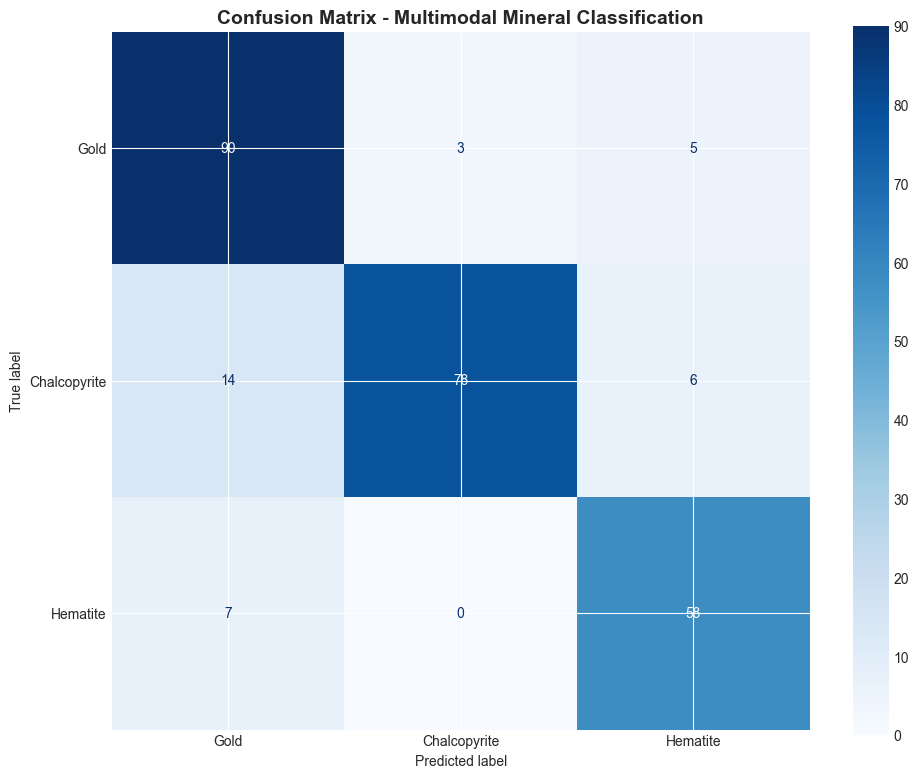


 Confusion Matrix Analysis:
   Gold: 90/98 correctly classified (91.8%)
   Chalcopyrite: 78/98 correctly classified (79.6%)
   Hematite: 58/65 correctly classified (89.2%)


In [17]:
# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Multimodal Mineral Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Confusion Matrix Analysis:")
for i, mineral in enumerate(class_names):
    true_positives = cm[i, i]
    total = cm[i].sum()
    accuracy = (true_positives / total) * 100 if total > 0 else 0
    print(f"   {mineral}: {true_positives}/{total} correctly classified ({accuracy:.1f}%)")

### 11.3 Detailed Metrics (Accuracy, Precision, Recall, F1)

In [18]:
# Calculate comprehensive metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)

# Macro-averaged metrics
macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()

# Calculate FPR and Specificity per class
fpr_per_class = []
specificity_per_class = []

for i in range(num_classes):
    tn = ((y_true != i) & (y_pred != i)).sum()
    fp = ((y_true != i) & (y_pred == i)).sum()
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    fpr_per_class.append(fpr)
    specificity_per_class.append(specificity)

macro_fpr = np.mean(fpr_per_class)
macro_specificity = np.mean(specificity_per_class)

# Print results
print("=" * 90)
print("MODEL EVALUATION METRICS")
print("=" * 90)

print("\n OVERALL METRICS:")
print(f"   Accuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Macro Precision:   {macro_precision:.4f} ({macro_precision*100:.2f}%)")
print(f"   Macro Recall:      {macro_recall:.4f} ({macro_recall*100:.2f}%)")
print(f"   Macro F1 Score:    {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"   Macro FPR:         {macro_fpr:.4f} ({macro_fpr*100:.2f}%)")
print(f"   Macro Specificity: {macro_specificity:.4f} ({macro_specificity*100:.2f}%)")

print("\n PER-CLASS METRICS:")
print(f"\n{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'FPR':<12} {'Specificity':<12} {'Support':<10}")
print("-" * 95)

for i, name in enumerate(class_names):
    print(f"{name:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} "
          f"{fpr_per_class[i]:<12.4f} {specificity_per_class[i]:<12.4f} {support[i]:<10d}")

print("\n" + "=" * 90)
print("\n CLASSIFICATION REPORT:")
print("\n" + classification_report(y_true, y_pred, target_names=class_names))

MODEL EVALUATION METRICS

 OVERALL METRICS:
   Accuracy:          0.8659 (86.59%)
   Macro Precision:   0.8715 (87.15%)
   Macro Recall:      0.8689 (86.89%)
   Macro F1 Score:    0.8661 (86.61%)
   Macro FPR:         0.0678 (6.78%)
   Macro Specificity: 0.9322 (93.22%)

 PER-CLASS METRICS:

Class           Precision    Recall       F1 Score     FPR          Specificity  Support   
-----------------------------------------------------------------------------------------------
Gold            0.8108       0.9184       0.8612       0.1288       0.8712       98        
Chalcopyrite    0.9630       0.7959       0.8715       0.0184       0.9816       98        
Hematite        0.8406       0.8923       0.8657       0.0561       0.9439       65        


 CLASSIFICATION REPORT:

              precision    recall  f1-score   support

        Gold       0.81      0.92      0.86        98
Chalcopyrite       0.96      0.80      0.87        98
    Hematite       0.84      0.89      0.87        65

---
#  Step 12: Visualize Feature Embeddings
Use dimensionality reduction to visualize how the model separates different mineral classes.

### 12.1 Extract Feature Embeddings

In [19]:
# Extract embeddings from fusion layer
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, audios, chemicals, labels in test_loader:
        images = images.to(device)
        audios = audios.to(device)
        chemicals = chemicals.to(device)
        
        # Get embeddings before classification layer
        f_img = model.image_enc(images)
        f_aud = model.audio_enc(audios)
        f_chem = model.chem_enc(chemicals)
        fused = torch.cat([f_img, f_aud, f_chem], dim=1)
        
        all_embeddings.append(fused.cpu().numpy())
        all_labels.append(labels.numpy())

embeddings = np.vstack(all_embeddings)
labels = np.concatenate(all_labels)

print(f" Extracted embeddings: {embeddings.shape}")
print(f"   Embedding dimension: {embeddings.shape[1]}")
print(f"   Number of samples: {embeddings.shape[0]}")

c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

 Extracted embeddings: (261, 224)
   Embedding dimension: 224
   Number of samples: 261


### 12.2 PCA Visualization

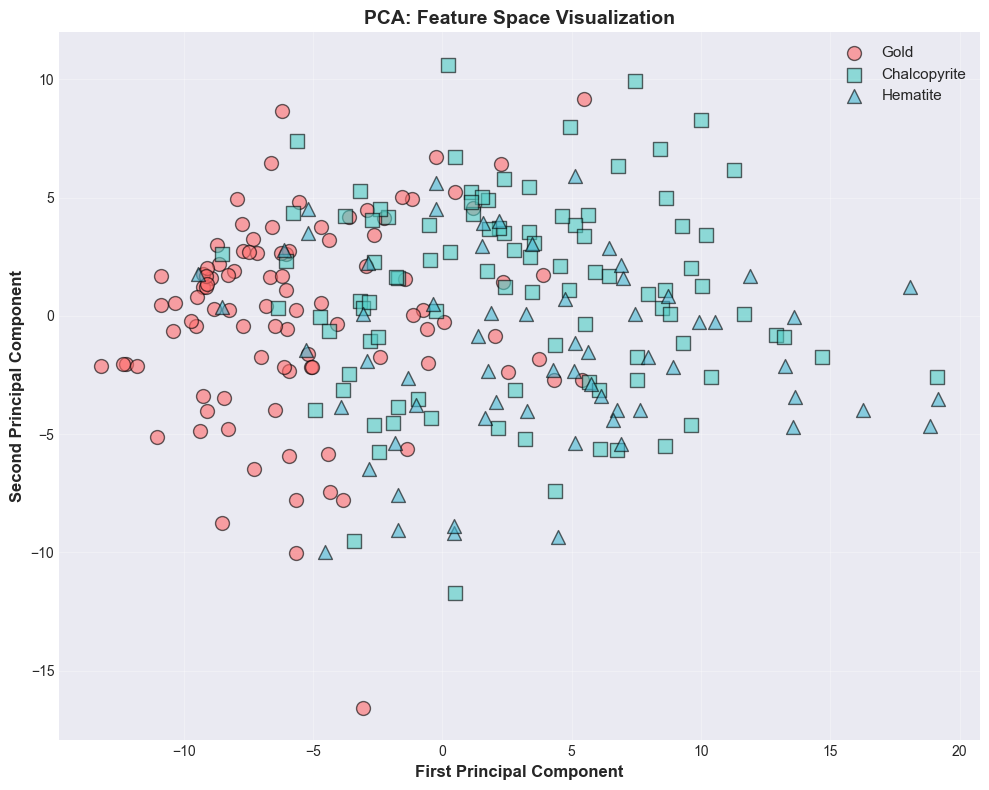


 PCA Explained Variance:
   PC1: 54.33%
   PC2: 20.52%
   Total: 74.85%


In [20]:
# Apply PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
markers = ['o', 's', '^']

for i, (name, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = labels == i
    plt.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1], 
                c=color, label=name, alpha=0.6, s=100, marker=marker, edgecolors='black')

plt.xlabel('First Principal Component', fontsize=12, fontweight='bold')
plt.ylabel('Second Principal Component', fontsize=12, fontweight='bold')
plt.title('PCA: Feature Space Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n PCA Explained Variance:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

### 12.3 t-SNE Visualization

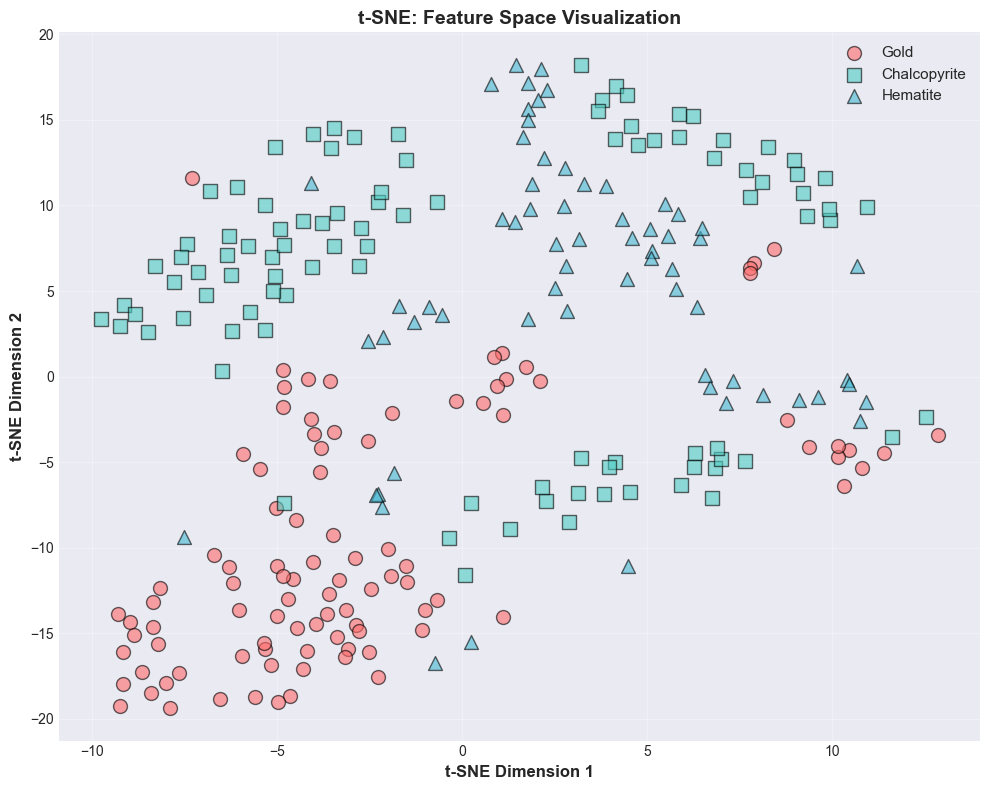


 t-SNE visualization shows how well the model separates different mineral classes!


In [21]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))

for i, (name, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = labels == i
    plt.scatter(embeddings_tsne[mask, 0], embeddings_tsne[mask, 1], 
                c=color, label=name, alpha=0.6, s=100, marker=marker, edgecolors='black')

plt.xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
plt.title('t-SNE: Feature Space Visualization', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n t-SNE visualization shows how well the model separates different mineral classes!")

## Open-Set Gate Model (Mineral vs Non-Mineral)
This section trains a binary image gate model using `gate_train.csv`, `gate_val.csv`, and `gate_test.csv`.

Artifacts saved for API use:
- `dataset/mineral_gate_model.pt`
- `dataset/mineral_gate_config.json`

In [22]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 3
LR = 1e-4
WEIGHT_DECAY = 1e-4

DATASET_DIR = Path('.').resolve()
TRAIN_CSV = DATASET_DIR / 'gate_train.csv'
VAL_CSV = DATASET_DIR / 'gate_val.csv'
TEST_CSV = DATASET_DIR / 'gate_test.csv'

MODEL_OUT = DATASET_DIR / 'mineral_gate_model.pt'
CONFIG_OUT = DATASET_DIR / 'mineral_gate_config.json'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Device: {DEVICE}')
print(f'Train CSV exists: {TRAIN_CSV.exists()}')
print(f'Val CSV exists: {VAL_CSV.exists()}')
print(f'Test CSV exists: {TEST_CSV.exists()}')

Device: cpu
Train CSV exists: True
Val CSV exists: True
Test CSV exists: True


In [29]:
class GateImageDataset(Dataset):
    def __init__(self, csv_path: Path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = DATASET_DIR / str(row['image_path'])
        label = float(row['label_id'])

        image = Image.open(image_path).convert('RGB')
        image = self.transform(image)

        return image, torch.tensor([label], dtype=torch.float32)


train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

gate_train_ds = GateImageDataset(TRAIN_CSV, train_tfms)
gate_val_ds = GateImageDataset(VAL_CSV, val_tfms)
gate_test_ds = GateImageDataset(TEST_CSV, val_tfms)

gate_train_loader = DataLoader(gate_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
gate_val_loader = DataLoader(gate_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
gate_test_loader = DataLoader(gate_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('Gate Model Datasets:')
print('Train size:', len(gate_train_ds))
print('Val size  :', len(gate_val_ds))
print('Test size :', len(gate_test_ds))

Gate Model Datasets:
Train size: 710
Val size  : 174
Test size : 520


In [30]:
def evaluate_probs(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.int32)
    acc = float((y_pred == y_true).mean())

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    return {
        'accuracy': acc,
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def collect_outputs(model, loader):
    model.eval()
    probs_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            labels = y.numpy().reshape(-1).astype(np.int32)
            probs_list.append(probs)
            labels_list.append(labels)

    y_prob = np.concatenate(probs_list)
    y_true = np.concatenate(labels_list)
    return y_true, y_prob


gate_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
gate_model.fc = nn.Linear(gate_model.fc.in_features, 1)
gate_model = gate_model.to(DEVICE)

gate_criterion = nn.BCEWithLogitsLoss()
gate_optimizer = torch.optim.AdamW(gate_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_state = None
best_val_f1 = -1.0
best_threshold = 0.5

for epoch in range(1, EPOCHS + 1):
    gate_model.train()
    running_loss = 0.0

    for x, y in gate_train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        gate_optimizer.zero_grad()
        logits = gate_model(x)
        loss = gate_criterion(logits, y)
        loss.backward()
        gate_optimizer.step()

        running_loss += float(loss.item())

    train_loss = running_loss / max(1, len(gate_train_loader))

    y_val_true, y_val_prob = collect_outputs(gate_model, gate_val_loader)

    thresholds = np.linspace(0.3, 0.8, 26)
    best_epoch_f1 = -1.0
    best_epoch_thr = 0.5
    best_epoch_metrics = None

    for thr in thresholds:
        m = evaluate_probs(y_val_true, y_val_prob, threshold=float(thr))
        if m['f1'] > best_epoch_f1:
            best_epoch_f1 = m['f1']
            best_epoch_thr = float(thr)
            best_epoch_metrics = m

    print(
        f"Epoch {epoch}/{EPOCHS} | loss={train_loss:.4f} | "
        f"val_acc={best_epoch_metrics['accuracy']:.4f} | "
        f"val_f1={best_epoch_metrics['f1']:.4f} | thr={best_epoch_thr:.2f}"
    )

    if best_epoch_f1 > best_val_f1:
        best_val_f1 = best_epoch_f1
        best_threshold = best_epoch_thr
        best_state = {
            'model_state_dict': gate_model.state_dict(),
            'threshold': best_threshold,
            'val_f1': best_val_f1,
            'epoch': epoch,
        }

if best_state is None:
    raise RuntimeError('Training failed: no checkpoint captured.')

# Save gate model (separate from multimodal model)
gated_model_path = DATASET_DIR / 'mineral_gate_model.pt'
torch.save(best_state, gated_model_path)

config = {
    'model_path': str(gated_model_path.name),
    'input_size': [224, 224],
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225],
    'threshold': float(best_threshold),
    'label_map': {'non_mineral': 0, 'mineral': 1},
    'backbone': 'resnet18',
}

gate_config_path = DATASET_DIR / 'mineral_gate_config.json'
with open(gate_config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)

print('Saved gate model:', gated_model_path)
print('Saved gate config:', gate_config_path)
print('Best val F1:', round(best_val_f1, 4), 'Threshold:', round(best_threshold, 3))

Epoch 1/3 | loss=0.2122 | val_acc=0.9885 | val_f1=0.9885 | thr=0.30
Epoch 2/3 | loss=0.0468 | val_acc=0.9828 | val_f1=0.9829 | thr=0.64
Epoch 3/3 | loss=0.0334 | val_acc=0.9770 | val_f1=0.9770 | thr=0.30
Saved gate model: C:\Users\HP\Mission-Capstone\dataset\mineral_gate_model.pt
Saved gate config: C:\Users\HP\Mission-Capstone\dataset\mineral_gate_config.json
Best val F1: 0.9885 Threshold: 0.3


In [31]:
# Load best checkpoint and report gate model test metrics
gate_checkpoint = torch.load(gated_model_path, map_location=DEVICE)
gate_model.load_state_dict(gate_checkpoint['model_state_dict'])
gate_model.eval()

gate_threshold = float(gate_checkpoint.get('threshold', 0.5))
y_test_true, y_test_prob = collect_outputs(gate_model, gate_test_loader)
gate_test_metrics = evaluate_probs(y_test_true, y_test_prob, threshold=gate_threshold)

print('Gate Model - Test metrics @ threshold', round(gate_threshold, 3))
for k in ['accuracy', 'precision', 'recall', 'f1', 'tp', 'tn', 'fp', 'fn']:
    print(f'{k}: {gate_test_metrics[k]}')

Gate Model - Test metrics @ threshold 0.3
accuracy: 0.9961538461538462
precision: 0.9923664122137366
recall: 0.9999999999999961
f1: 0.9961685823749751
tp: 260
tn: 258
fp: 2
fn: 0


## Confidence Calibration (Temperature Scaling)
This section calibrates softmax confidence using validation logits and saves calibration metadata for API inference.

In [33]:
import json

# ✅ CRITICAL: Reload multimodal model (may have been overwritten by gate model code)
print("=" * 80)
print("CONFIDENCE CALIBRATION - TEMPERATURE SCALING")
print("=" * 80)

# Reload the trained multimodal model from saved weights
print("\nReloading trained multimodal model...")
multimodal_model = MultiModalNet(num_classes=num_classes).to(device)
multimodal_model.load_state_dict(torch.load('multimodal_model.pt', map_location=device))
multimodal_model.eval()
print("✓ Multimodal model loaded successfully")

# Recreate multimodal loaders (gate model code may have overwritten them)
multimodal_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
multimodal_test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n Multimodal loaders restored for calibration:")
print(f"   Val batches: {len(multimodal_val_loader)}")
print(f"   Test batches: {len(multimodal_test_loader)}\n")

def collect_logits_and_labels(model, loader, device):
    """Collect logits and labels from multimodal model."""
    model.eval()
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for images, audios, chemicals, labels in loader:
            images = images.to(device)
            audios = audios.to(device)
            chemicals = chemicals.to(device)
            logits = model(images, audios, chemicals)
            logits_list.append(logits)
            labels_list.append(labels.to(device))
    return torch.cat(logits_list, dim=0), torch.cat(labels_list, dim=0)


def nll_with_temperature(logits, labels, temperature):
    """Compute negative log-likelihood with temperature scaling."""
    scaled = logits / temperature
    return torch.nn.functional.cross_entropy(scaled, labels)


# Collect logits from multimodal model
print("Collecting logits from validation and test sets...")
val_logits, val_labels = collect_logits_and_labels(multimodal_model, multimodal_val_loader, device)
test_logits, test_labels = collect_logits_and_labels(multimodal_model, multimodal_test_loader, device)

print("✓ Logits collected successfully\n")

# Optimize scalar temperature on validation set
log_temperature = torch.tensor([0.0], device=device, requires_grad=True)  # temp starts at exp(0)=1.0
optimizer_temp = torch.optim.LBFGS([log_temperature], lr=0.1, max_iter=50)


def closure():
    optimizer_temp.zero_grad()
    temperature = torch.exp(log_temperature)
    loss = nll_with_temperature(val_logits, val_labels, temperature)
    loss.backward()
    return loss

print("Optimizing temperature... ", end="")
optimizer_temp.step(closure)
optimized_temperature = float(torch.exp(log_temperature).detach().cpu().item())
print(f"Done!")

# Safety clamp
optimized_temperature = max(0.5, min(5.0, optimized_temperature))

val_nll_before = float(torch.nn.functional.cross_entropy(val_logits, val_labels).item())
val_nll_after = float(torch.nn.functional.cross_entropy(val_logits / optimized_temperature, val_labels).item())

def confidence_stats(logits):
    """Compute confidence statistics."""
    probs = torch.softmax(logits, dim=1)
    conf = probs.max(dim=1).values.cpu().numpy()
    return {
        'mean': float(conf.mean()),
        'p95+': float((conf >= 0.95).mean()),
        'p99+': float((conf >= 0.99).mean()),
        'p999+': float((conf >= 0.999).mean()),
        'min': float(conf.min()),
        'max': float(conf.max()),
    }

test_conf_before = confidence_stats(test_logits)
test_conf_after = confidence_stats(test_logits / optimized_temperature)

calibration = {
    'temperature': optimized_temperature,
    'val_nll_before': val_nll_before,
    'val_nll_after': val_nll_after,
    'test_conf_before': test_conf_before,
    'test_conf_after': test_conf_after,
    'note': 'Apply softmax(logits / temperature) at inference',
}

with open('multimodal_calibration.json', 'w', encoding='utf-8') as f:
    json.dump(calibration, f, indent=2)

print("\n" + "=" * 80)
print("CALIBRATION COMPLETE")
print("=" * 80)
print(f'\nOptimized temperature: {round(optimized_temperature, 4)}')
print(f'Val NLL before/after: {round(val_nll_before, 4)} → {round(val_nll_after, 4)}')
print(f'Saved calibration file: multimodal_calibration.json')
print(f'\nTest confidence before calibration:')
for k, v in test_conf_before.items():
    print(f'  {k}: {v:.4f}')
print(f'\nTest confidence after calibration:')
for k, v in test_conf_after.items():
    print(f'  {k}: {v:.4f}')

CONFIDENCE CALIBRATION - TEMPERATURE SCALING

Reloading trained multimodal model...
✓ Multimodal model loaded successfully

 Multimodal loaders restored for calibration:
   Val batches: 12
   Test batches: 33



c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warnings.warn(
c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=600
  warning

✓ Logits collected successfully

Optimizing temperature... Done!

CALIBRATION COMPLETE

Optimized temperature: 0.7651
Val NLL before/after: 0.2157 → 0.2035
Saved calibration file: multimodal_calibration.json

Test confidence before calibration:
  mean: 0.8192
  p95+: 0.2720
  p99+: 0.0038
  p999+: 0.0000
  min: 0.3783
  max: 0.9903

Test confidence after calibration:
  mean: 0.8654
  p95+: 0.5019
  p99+: 0.1571
  p999+: 0.0000
  min: 0.3923
  max: 0.9980
